# EXPLORATORY DATA ANALYSIS (EDA)  
#### Uncovering Insights and Patterns in the Dataset  

Exploratory Data Analysis (EDA) is a critical step in understanding the structure, relationships, and potential issues within the dataset. This phase involves summarizing the main characteristics of the data, visualizing distributions, and identifying trends, outliers, and anomalies.  

The goal of EDA is to:  
1. **Understand the Data**: Gain insights into the dataset's structure, features, and distributions.  
2. **Identify Patterns**: Detect trends, correlations, and relationships between variables.  
3. **Spot Issues**: Identify missing values, outliers, or inconsistencies that may impact analysis.  
4. **Inform Preprocessing**: Guide decisions on data cleaning, transformation, and feature engineering.  

In this section, we will explore the dataset through summary statistics, visualizations, and key insights to prepare it for further analysis and modeling.  

In [16]:
# load the clean dataset
import pandas as pd

df = pd.read_parquet(r"C:\Users\zeid9\Documents\Scalable-MLOps-Pipeline-for-Credit-Risk-Prediction\data\df_clean_2025-07-21.parquet")

## EXPLORING CATEGORICAL COLUMNS  
#### Analyzing Unique Values in Categorical Features  

In this step, categorical columns in the dataset are examined to understand their unique values and diversity. This analysis helps identify potential issues such as high cardinality, inconsistent categories, or the need for encoding during preprocessing.  

In [17]:
# Identify categorical columns in the dataset
categorical_columns = df_clean.select_dtypes(include='object').columns

# Display unique values for each categorical column
print("Unique Values in Categorical Columns:\n")
for column in categorical_columns:
    unique_values = df_clean[column].unique()
    print(f"Column: {column}")
    print(f"  - Number of Unique Values: {len(unique_values)}")
    print(f"  - Unique Values: {unique_values}\n")

# Display the total number of categorical columns
num_categorical_columns = len(categorical_columns)
print(f"Total number of categorical columns: {num_categorical_columns}")

Unique Values in Categorical Columns:

Column: home_status
  - Number of Unique Values: 4
  - Unique Values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Column: loan_intent
  - Number of Unique Values: 6
  - Unique Values: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

Column: loan_grade
  - Number of Unique Values: 7
  - Unique Values: ['D' 'B' 'C' 'A' 'E' 'F' 'G']

Column: default
  - Number of Unique Values: 2
  - Unique Values: ['Y' 'N']

Total number of categorical columns: 4


# VISUALIZING NUMERICAL VARIABLES  
#### Density Plots for Distribution Analysis  

This step uses **density plots** to visualize the distribution of numerical variables. It helps identify patterns, peaks, and skewness in the data.

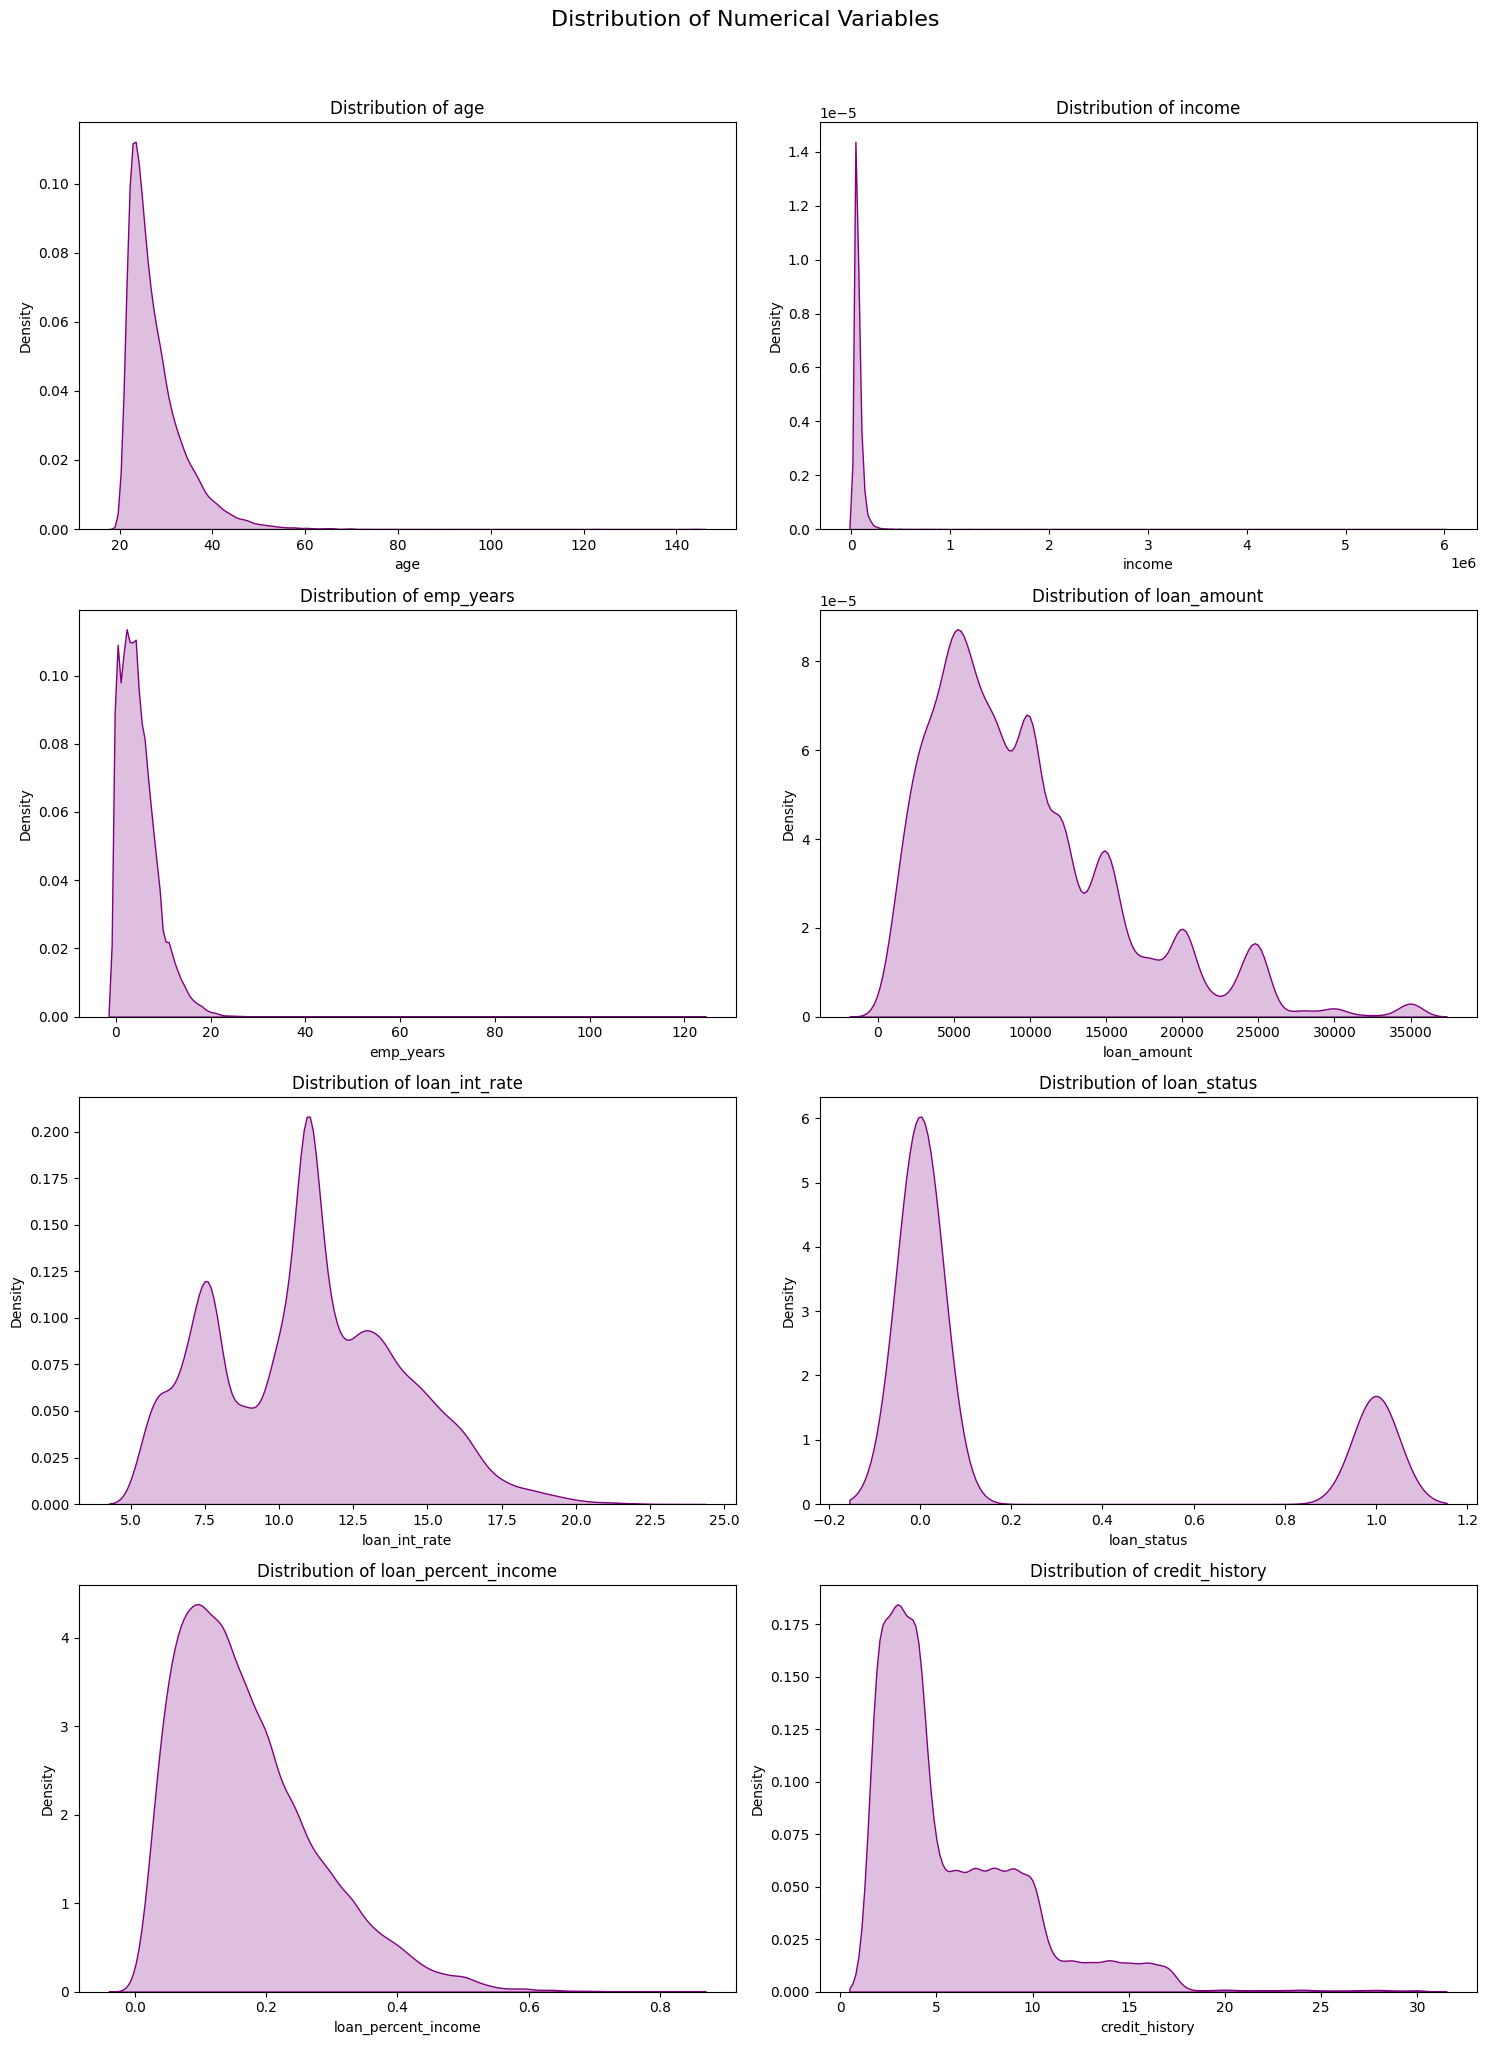

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns
numerical_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Set up the subplot grid
num_cols = len(numerical_columns)
fig, axes = plt.subplots(
    nrows=(num_cols + 1) // 2, ncols=2,
    figsize=(15, 5 * ((num_cols + 1) // 2))
)
fig.suptitle("Distribution of Numerical Variables", fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot density plots for each numerical column
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_clean[col], ax=axes[i], color='purple', fill=True)
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Density", fontsize=10)

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


# VISUALIZING DEFAULT DISTRIBUTION  
#### Donut Chart for Defaulters  

This step visualizes the distribution of defaulters in the `credit_default` column using a **donut chart**. The chart shows the proportion of defaulters vs. non-defaulters, making it easy to understand the balance (or imbalance) in the dataset. 

C:\Users\zeid9\AppData\Local\Temp\ipykernel_10340\4212709541.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  set2_colors = cm.get_cmap('Set3', len(default_counts))
C:\Users\zeid9\AppData\Local\Temp\ipykernel_10340\4212709541.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)


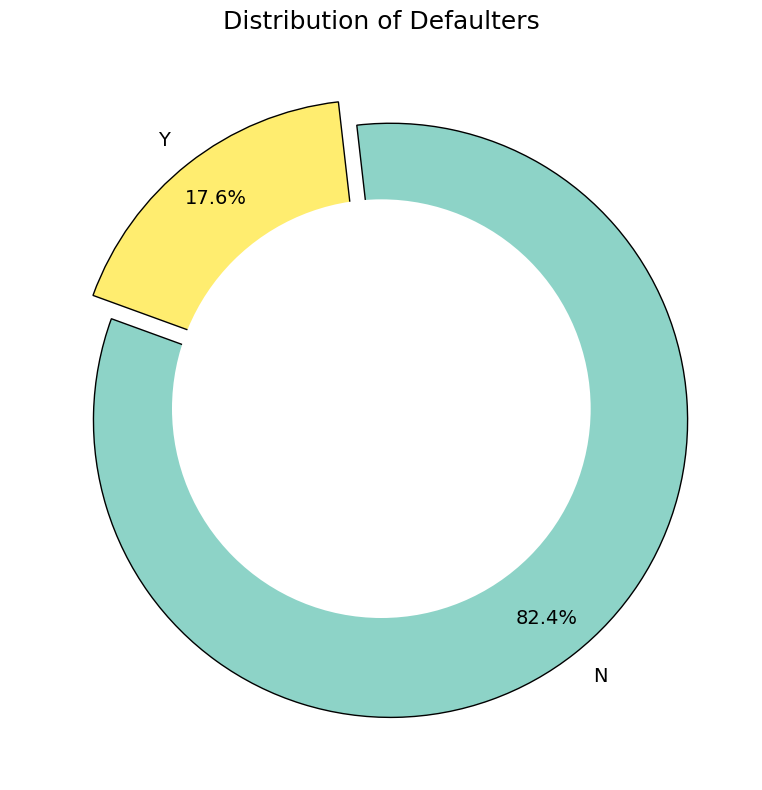

default
N    26836
Y     5745
Name: count, dtype: int64

In [20]:
from matplotlib import cm
# Count the occurrences of each value in the 'credit_default' column
default_counts = df['default'].value_counts()

# Get colors from the 'Set2' colormap
set2_colors = cm.get_cmap('Set3', len(default_counts))

# Plot a simplified donut chart
plt.figure(figsize=(8, 8))

# Explode the slices for a dynamic look
explode = (0.05, 0.05)  # Slightly separate the slices

# Plot the pie chart with custom styling
wedges, texts, autotexts = plt.pie(
    default_counts, 
    labels=default_counts.index, 
    autopct='%1.1f%%', 
    startangle=160, 
    pctdistance=0.85, 
    colors=set2_colors.colors, 
    textprops={'fontsize': 14,'color': 'black'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},  # Add edge styling
    explode=explode  # Explode the slices
)

# Draw a circle in the middle to make it a donut chart
circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)
plt.gca().add_artist(circle)

# Add a title with custom styling
plt.title(
    'Distribution of Defaulters', 
    fontsize=18
)

# Improve layout and spacing
plt.tight_layout()

# Show the chart
plt.show()

# Get value counts
df['default'].value_counts()




### LOAN INTENT DISTRIBUTION

C:\Users\zeid9\AppData\Local\Temp\ipykernel_10340\1869891986.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)


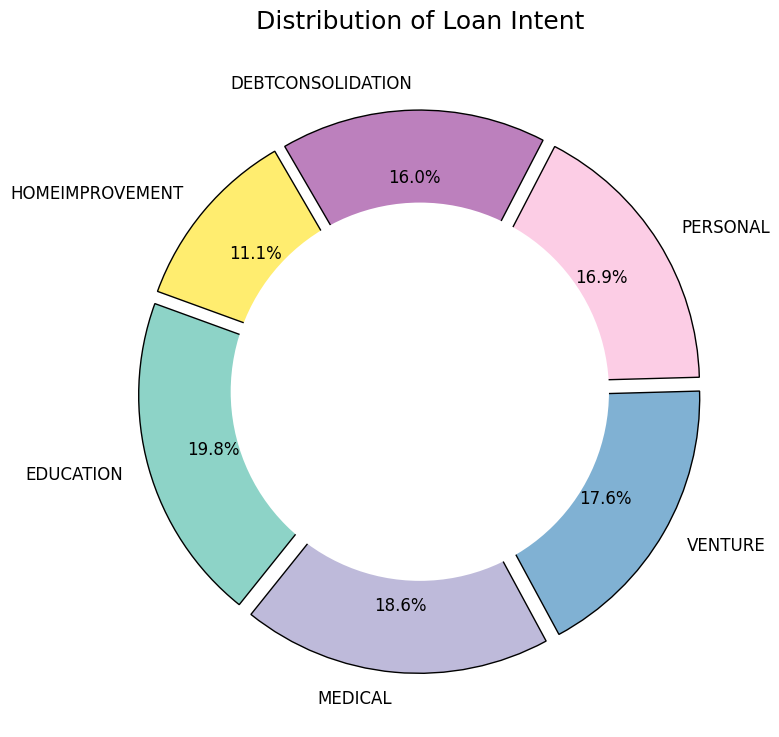

In [22]:
# Count the occurrences of each value in the 'loan_intent' column
intent_counts = df['loan_intent'].value_counts()

# Get colors from the 'Set3' colormap
set2_colors = plt.get_cmap('Set3', len(intent_counts))

# Plot a simplified donut chart
plt.figure(figsize=(8, 8))

# Explode the slices for a dynamic look
explode = [0.05] * len(intent_counts)  # Slightly separate all slices

# Plot the pie chart with custom styling
wedges, texts, autotexts = plt.pie(
    intent_counts, 
    labels=intent_counts.index, 
    autopct='%1.1f%%', 
    startangle=160, 
    pctdistance=0.75,  # Adjust percentage label distance
    colors=set2_colors.colors, 
    textprops={'fontsize': 12, 'color': 'black'},  # Adjust font size
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},  # Add edge styling
    explode=explode  # Explode the slices
)

# Draw a circle in the middle to make it a donut chart
circle = plt.Circle((0, 0), 0.70, color='white', fc='white', edgecolor='black', linewidth=2)
plt.gca().add_artist(circle)

# Add a title with custom styling
plt.title('Distribution of Loan Intent', fontsize=18, pad=20)

# Improve layout and spacing
plt.tight_layout()

# Show the chart
plt.show()

C:\Users\zeid9\AppData\Local\Temp\ipykernel_10340\2775642963.py:41: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


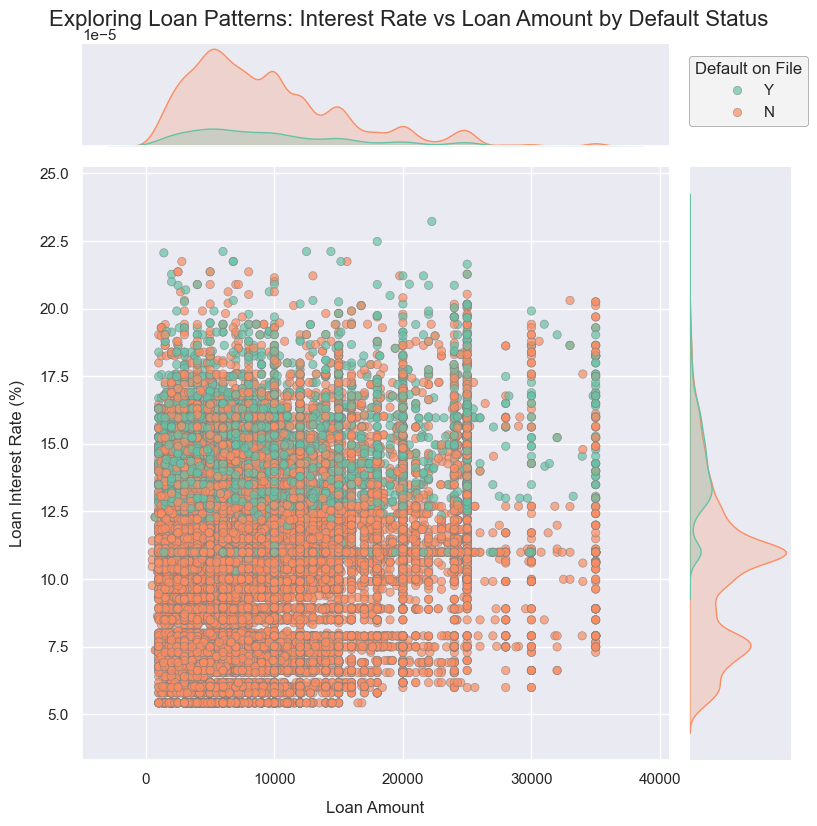

In [24]:
# Set seaborn theme to "whitegrid" for a cleaner look
sns.set_theme(style="darkgrid")

# Create a scatter plot with marginal distributions
plot = sns.jointplot(
    data=df,
    x='loan_amount',
    y='loan_int_rate',
    hue="default",
    palette="Set2",
    kind="scatter",
    height=8,
    alpha=0.7,
    edgecolor='gray',
    linewidth=0.5
)

# Customize axis labels
plot.ax_joint.set_xlabel("Loan Amount", fontsize=12, labelpad=10)
plot.ax_joint.set_ylabel("Loan Interest Rate (%)", fontsize=12, labelpad=10)

# Add main title with spacing and formatting
plot.figure.suptitle(
    "Exploring Loan Patterns: Interest Rate vs Loan Amount by Default Status",
    y=1.02, fontsize=16
)

# Customize legend for better visibility
legend = plot.ax_joint.legend(title="Default on File", bbox_to_anchor=(1.02, 1.2), loc='upper left')
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(0.5)
legend.get_frame().set_facecolor('#f0f0f0')

# Enhance marginal plots
plot.ax_marg_x.grid(False)
plot.ax_marg_y.grid(False)
plot.ax_marg_x.tick_params(axis='x', length=0)
plot.ax_marg_y.tick_params(axis='y', length=0)

# Adjust layout for better display
plt.tight_layout()
plt.show()


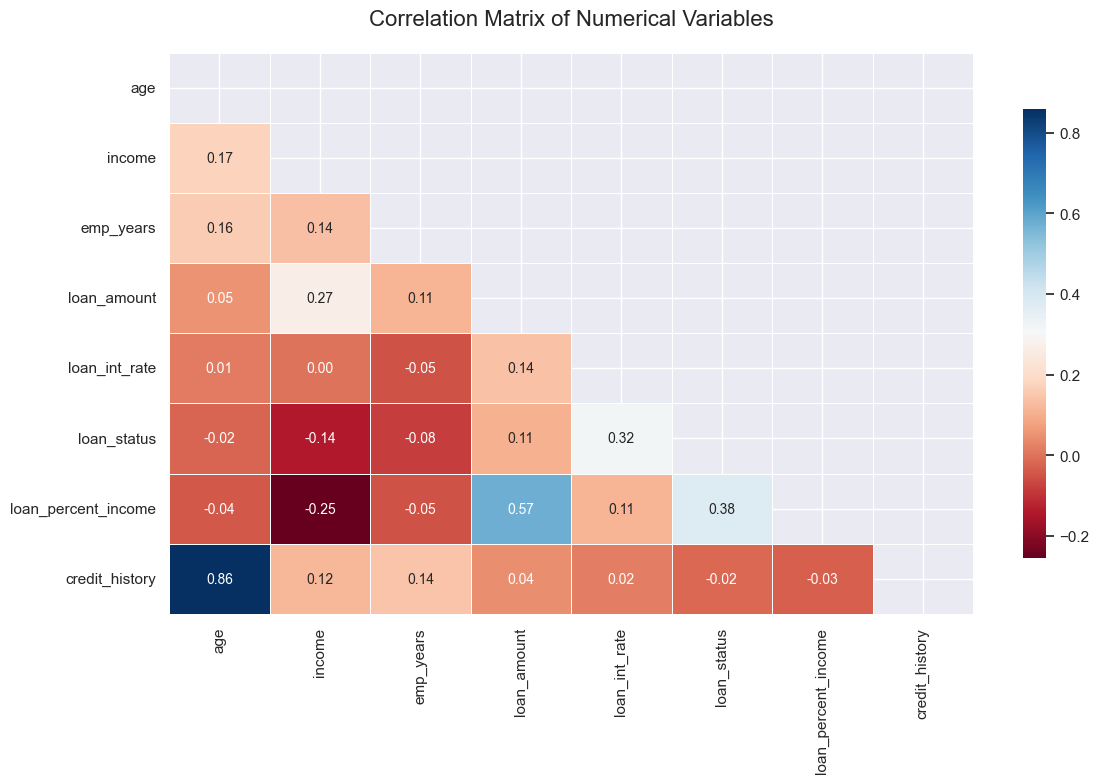

In [25]:
import numpy as np
# Set up the figure size for better readability
plt.figure(figsize=(12, 8))

# Calculate the correlation matrix for numerical variables
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.mask(mask)

# Create a heatmap using the 'RdBu' color scheme
sns.heatmap(
    corr_masked,
    annot=True,
    cmap='RdBu',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

# Add a title to the heatmap for context
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, pad=20)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the heatmap
plt.show()


## Correlation Matrix

a **correlation matrix** to visualize relationships between numerical variables in the dataset. It helps identify:

1. **Strong positive or negative correlations** between features.
2. **Multicollinearity** (high correlation between independent variables). Age and credit_history
3. **Relevance of features** to the target variable (if included).

In short, it’s a tool for understanding relationships and guiding feature selection in data analysis or modeling.